In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
COLORS = sns.color_palette("Set2", 3)

In [3]:
df = pd.read_csv("raw data.csv").reset_index(drop=True)

numeric_cols = [
    "Close", "High", "Low", "Open", "Volume",
    "Return", "MA10", "MA50", "Volatility",
    "Price_Change", "Volume_Change", "Trend", "Target"
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
df[["Date", "Close", "Return", "Target"]].head()

Rows: 2529, Columns: 14
Date range: 2016-03-15 → 2026-04-02


,Date,Close,Return,Target
0,2016-03-15,23.685326,0.020094,1.0
1,2016-03-16,24.000137,0.013291,0.0
2,2016-03-17,23.961637,-0.001604,1.0
3,2016-03-18,23.988817,0.001134,0.0
4,2016-03-21,23.986546,-0.000095,1.0


In [4]:
# RSI (14-day)
delta = df["Close"].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = -delta.clip(upper=0).rolling(14).mean()
df["RSI"] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

# MACD and signal line
ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"]        = ema12 - ema26
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
df["MACD_Hist"]   = df["MACD"] - df["MACD_Signal"]

print("RSI and MACD added.")
df[["Date", "RSI", "MACD", "MACD_Signal"]].tail()

RSI and MACD added.


,Date,RSI,MACD,MACD_Signal
2524,2026-03-30,27.964006,-3.853260,-3.528248
2525,2026-03-31,41.082305,-3.404243,-3.503447
2526,2026-04-01,49.820208,-2.866872,-3.376132
2527,2026-04-02,59.415598,-2.390052,-3.178916
2528,NaT,NaN,-2.390052,-3.021143


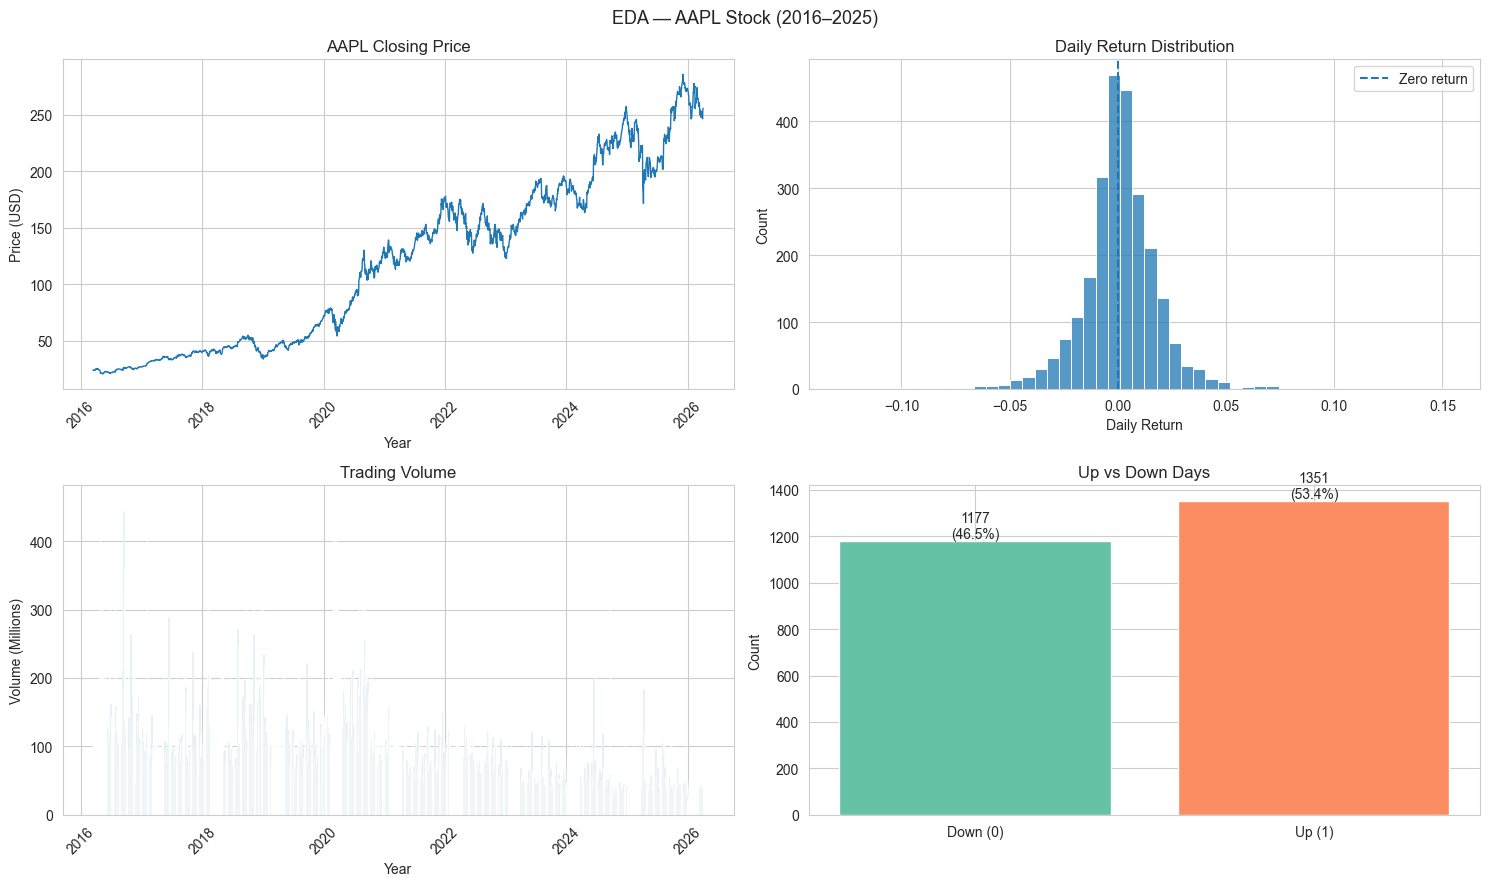

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# Price over time
axes[0, 0].plot(df["Date"], df["Close"], linewidth=1)
axes[0, 0].set(title="AAPL Closing Price", xlabel="Year", ylabel="Price (USD)")
axes[0, 0].tick_params(axis="x", rotation=45)

# Return distribution
sns.histplot(df["Return"].dropna(), bins=50, ax=axes[0, 1])
axes[0, 1].axvline(0, linestyle="--", label="Zero return")
axes[0, 1].set(title="Daily Return Distribution", xlabel="Daily Return", ylabel="Count")
axes[0, 1].legend()

# Volume
axes[1, 0].bar(df["Date"], df["Volume"] / 1_000_000, alpha=0.7)
axes[1, 0].set(title="Trading Volume", xlabel="Year", ylabel="Volume (Millions)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Target balance
counts = df["Target"].value_counts().sort_index()
bars = axes[1, 1].bar(["Down (0)", "Up (1)"], counts.values, color=COLORS[:2])
for bar, val in zip(bars, counts.values):
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2, val,
        f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom"
    )
axes[1, 1].set(title="Up vs Down Days", ylabel="Count")

plt.suptitle("EDA — AAPL Stock (2016–2025)", fontsize=13)
plt.tight_layout()
plt.show()

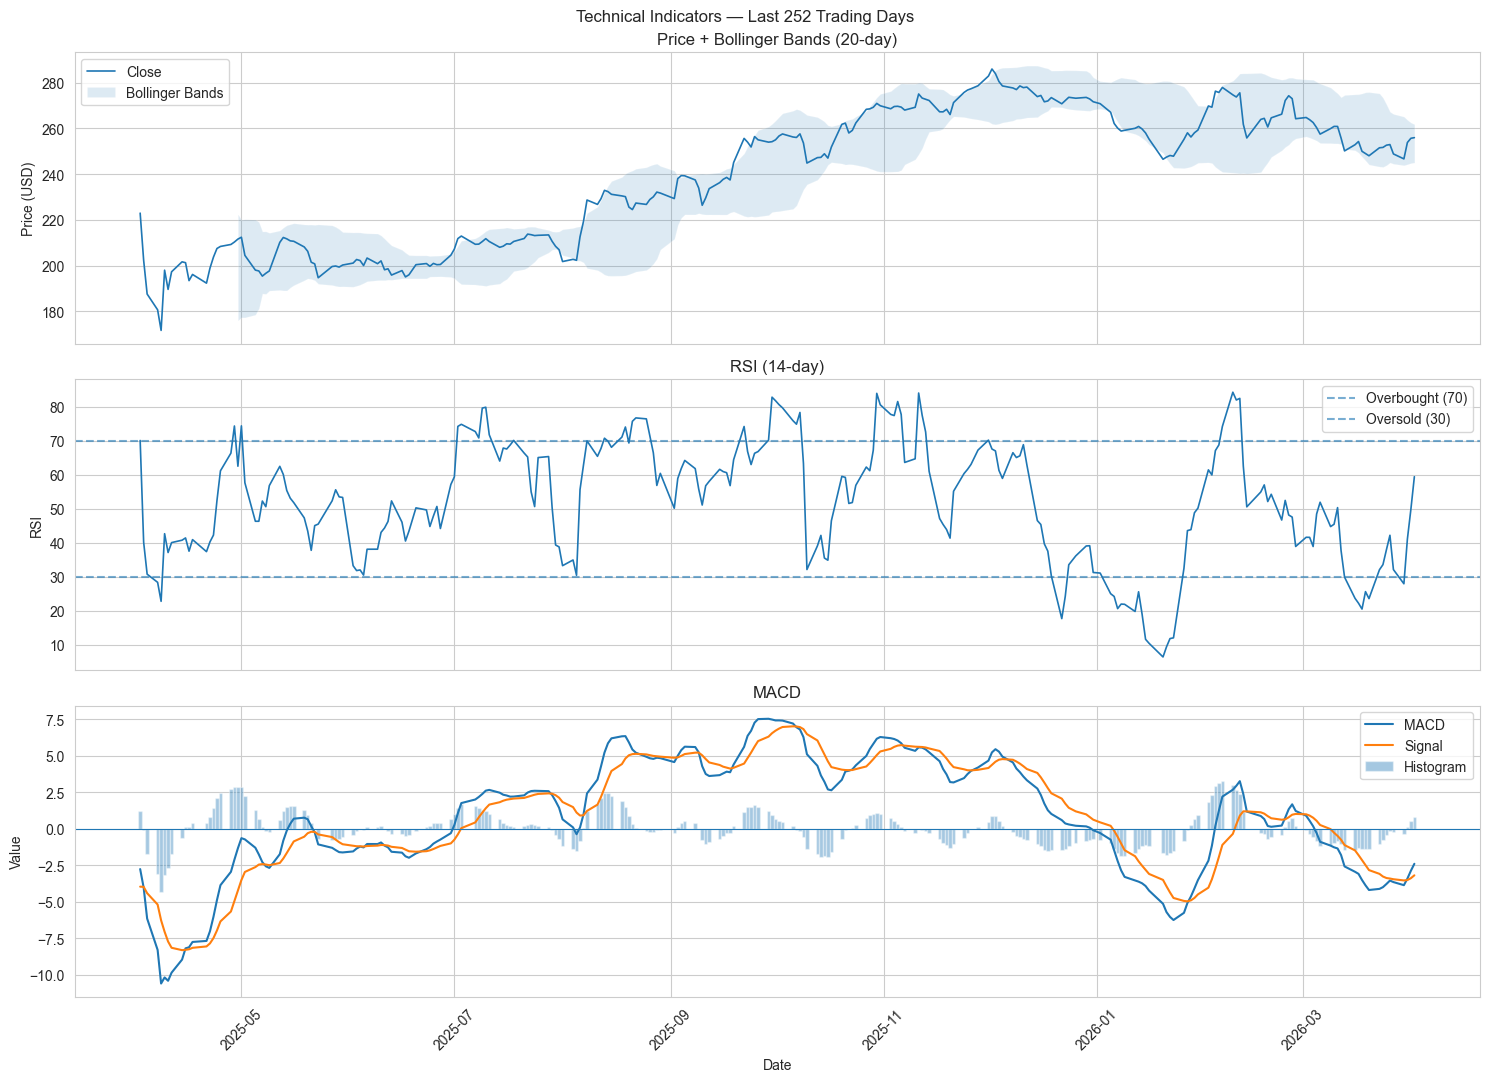

In [6]:
df = df.dropna().reset_index(drop=True)
recent = df.tail(252).copy()

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

# Bollinger Bands
rolling_mean = recent["Close"].rolling(20).mean()
rolling_std  = recent["Close"].rolling(20).std()
axes[0].plot(recent["Date"], recent["Close"], linewidth=1.2, label="Close")
axes[0].fill_between(
    recent["Date"],
    rolling_mean - 2 * rolling_std,
    rolling_mean + 2 * rolling_std,
    alpha=0.15, label="Bollinger Bands"
)
axes[0].set(title="Price + Bollinger Bands (20-day)", ylabel="Price (USD)")
axes[0].legend()

# RSI
axes[1].plot(recent["Date"], recent["RSI"], linewidth=1.2)
axes[1].axhline(70, linestyle="--", alpha=0.6, label="Overbought (70)")
axes[1].axhline(30, linestyle="--", alpha=0.6, label="Oversold (30)")
axes[1].set(title="RSI (14-day)", ylabel="RSI")
axes[1].legend()

# MACD
axes[2].plot(recent["Date"], recent["MACD"],        label="MACD",   linewidth=1.5)
axes[2].plot(recent["Date"], recent["MACD_Signal"], label="Signal", linewidth=1.5)
axes[2].bar(recent["Date"], recent["MACD_Hist"], alpha=0.4, width=1, label="Histogram")
axes[2].axhline(0, linewidth=0.8)
axes[2].set(title="MACD", ylabel="Value", xlabel="Date")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle("Technical Indicators — Last 252 Trading Days")
plt.tight_layout()
plt.show()

In [7]:
FEATURES = [
    "Return", "MA10", "MA50", "Volatility",
    "Price_Change", "Volume_Change", "Trend",
    "RSI", "MACD", "MACD_Signal", "MACD_Hist"
]

df_model = df[["Date"] + FEATURES + ["Target"]].dropna().reset_index(drop=True)

X = df_model[FEATURES]
y = df_model["Target"]

# Chronological 80/20 split — no shuffling for time series
split      = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Logistic Regression needs scaling; tree models don't
scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)
X_test_s   = scaler.transform(X_test)

print(f"Total rows : {len(df_model)}")
print(f"Train rows : {len(X_train)}")
print(f"Test rows  : {len(X_test)}")

Total rows : 2514
Train rows : 2011
Test rows  : 503


In [8]:
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=10, random_state=42
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_depth=4, learning_rate=0.05, max_iter=200, random_state=42
    ),
}

tscv    = TimeSeriesSplit(n_splits=5)
results = {}

print(f"{'Model':<26}  {'CV Acc':>8}  {'Test Acc':>10}  {'ROC-AUC':>9}")
print("-" * 60)

for name, model in MODELS.items():
    X_tr = X_train_s if name == "Logistic Regression" else X_train
    X_te = X_test_s  if name == "Logistic Regression" else X_test

    cv_scores = cross_val_score(model, X_tr, y_train, cv=tscv, scoring="accuracy")
    model.fit(X_tr, y_train)

    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]
    acc   = accuracy_score(y_test, preds)
    auc   = roc_auc_score(y_test, probs)

    results[name] = {
        "cv_acc": round(cv_scores.mean(), 4),
        "cv_std": round(cv_scores.std(), 4),
        "test_acc": round(acc, 4),
        "roc_auc": round(auc, 4),
        "model": model,
        "preds": preds,
        "probs": probs,
    }
    print(f"{name:<26}  {cv_scores.mean():>8.4f}  {acc:>10.4f}  {auc:>9.4f}")

Model                         CV Acc    Test Acc    ROC-AUC
------------------------------------------------------------
Logistic Regression           0.5242      0.4831     0.5169
Random Forest                 0.5093      0.4553     0.5391
Hist Gradient Boosting        0.5110      0.4652     0.5313


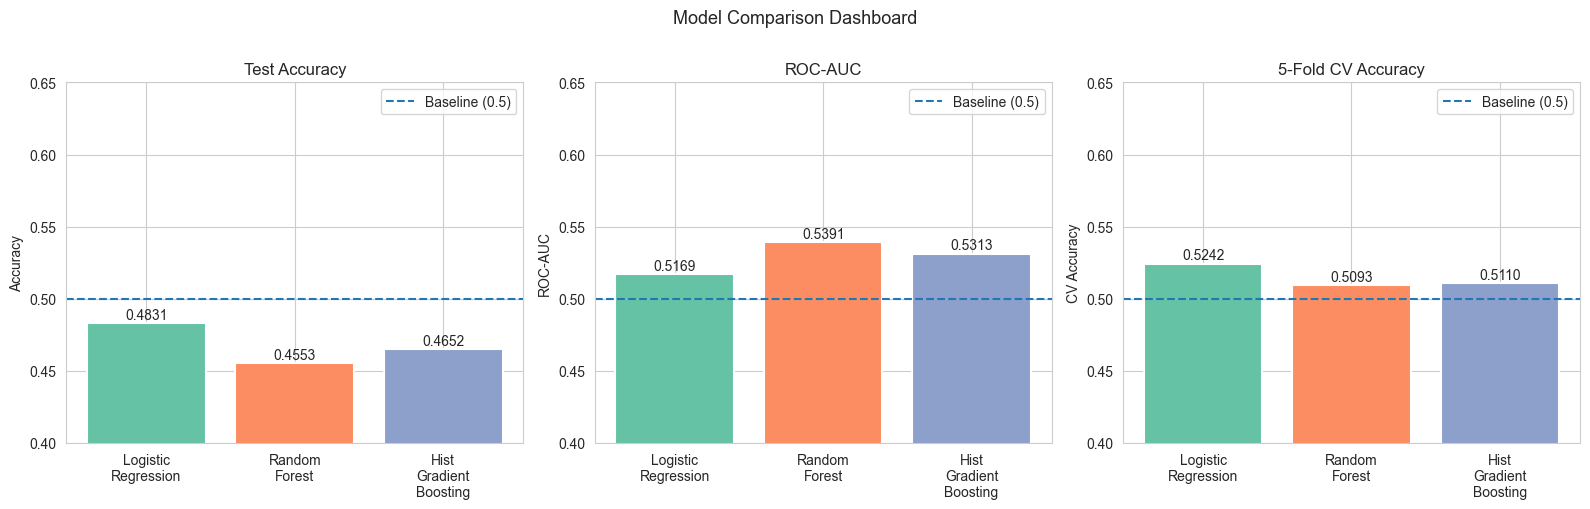

                 Model  CV Accuracy  Test Accuracy  ROC-AUC
         Random Forest       0.5093         0.4553   0.5391
Hist Gradient Boosting       0.5110         0.4652   0.5313
   Logistic Regression       0.5242         0.4831   0.5169


In [9]:
model_names = list(results.keys())
test_accs   = [results[m]["test_acc"] for m in model_names]
aucs        = [results[m]["roc_auc"]  for m in model_names]
cv_accs     = [results[m]["cv_acc"]   for m in model_names]
cv_stds     = [results[m]["cv_std"]   for m in model_names]

x      = np.arange(len(model_names))
labels = [n.replace(" ", "\n") for n in model_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, vals, title, ylbl in zip(
    axes,
    [test_accs, aucs, cv_accs],
    ["Test Accuracy", "ROC-AUC", "5-Fold CV Accuracy"],
    ["Accuracy", "ROC-AUC", "CV Accuracy"]
):
    bars = ax.bar(x, vals, color=COLORS, edgecolor="white", linewidth=1.5)
    ax.axhline(0.5, linestyle="--", linewidth=1.5, label="Baseline (0.5)")
    ax.set(title=title, ylabel=ylbl, ylim=(0.40, 0.65))
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.003, f"{val:.4f}", ha="center")

plt.suptitle("Model Comparison Dashboard", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "Model": model_names,
    "CV Accuracy": cv_accs,
    "Test Accuracy": test_accs,
    "ROC-AUC": aucs,
}).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

summary.to_csv("model_comparison.csv", index=False)
print(summary.to_string(index=False))

Best model: Random Forest  (ROC-AUC = 0.5391)

              precision    recall  f1-score   support

    Down (0)       0.95      0.45      0.61       473
      Up (1)       0.06      0.60      0.12        30

    accuracy                           0.46       503
   macro avg       0.51      0.52      0.36       503
weighted avg       0.89      0.46      0.58       503



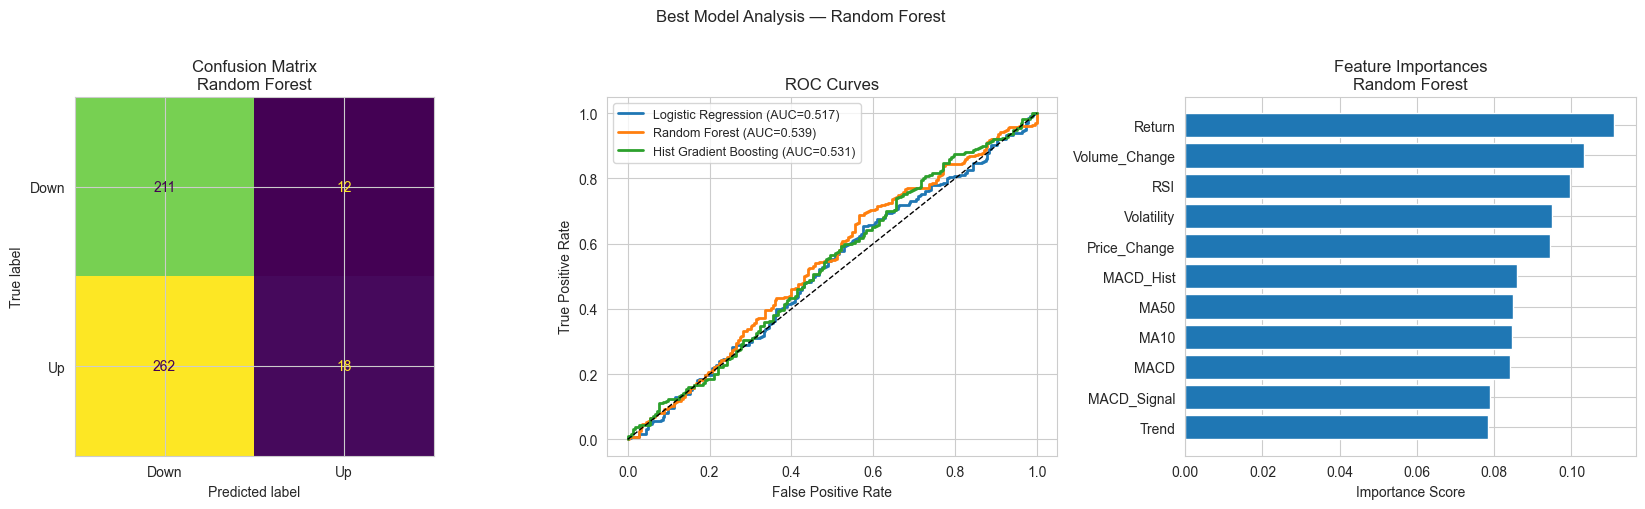

In [10]:
best_name = summary.iloc[0]["Model"]
best      = results[best_name]

print(f"Best model: {best_name}  (ROC-AUC = {best['roc_auc']})")
print()
print(classification_report(best["preds"], y_test, target_names=["Down (0)", "Up (1)"]))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion matrix
cm = confusion_matrix(y_test, best["preds"])
ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion Matrix\n{best_name}")

# ROC curves — all models
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["probs"])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set(title="ROC Curves", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[1].legend(fontsize=9)

# Feature importances (tree models only)
if hasattr(best["model"], "feature_importances_"):
    fi = pd.DataFrame({
        "Feature": FEATURES,
        "Importance": best["model"].feature_importances_
    }).sort_values("Importance")
    axes[2].barh(fi["Feature"], fi["Importance"])
    axes[2].set(title=f"Feature Importances\n{best_name}", xlabel="Importance Score")
else:
    axes[2].text(0.5, 0.5, "Not available for this model",
                 ha="center", va="center", transform=axes[2].transAxes)
    axes[2].set_title("Feature Importances")

plt.suptitle(f"Best Model Analysis — {best_name}", y=1.01)
plt.tight_layout()
plt.show()

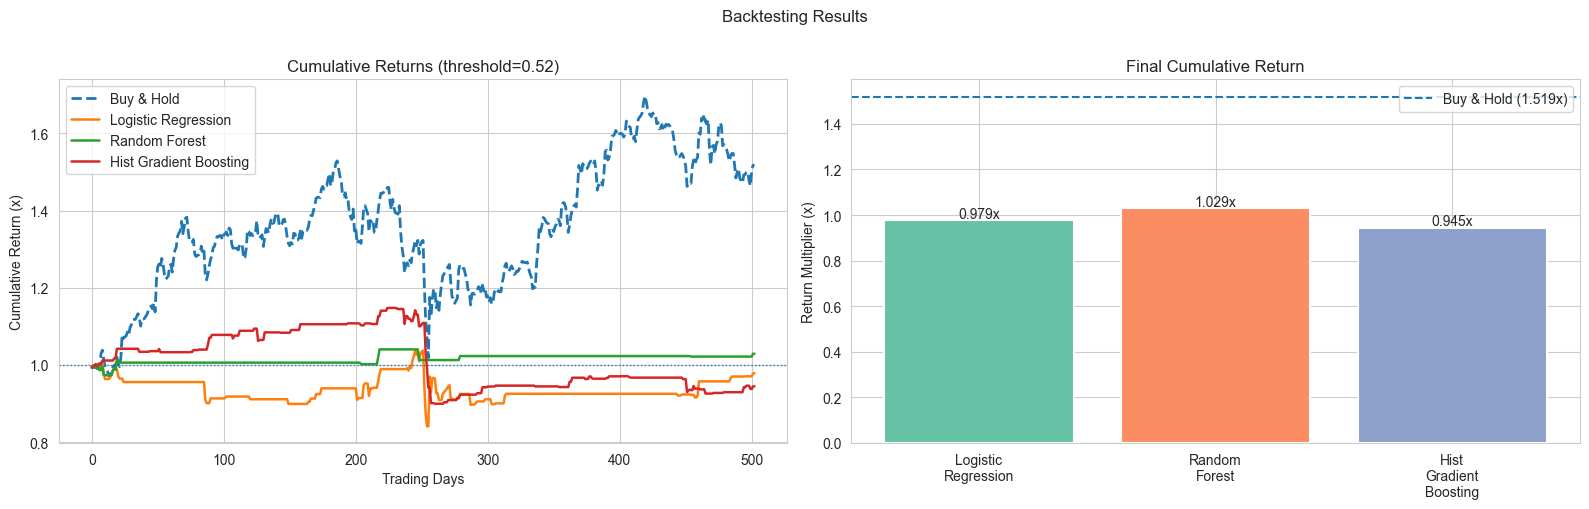

Strategy Stats:
                 Model  Trades  Win Rate  Final Return
   Logistic Regression      89     0.629         0.979
         Random Forest      21     0.524         1.029
Hist Gradient Boosting      92     0.598         0.945


In [11]:
THRESHOLD    = 0.52
returns_test = df_model["Return"].iloc[split:].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

buy_hold_cumul = (1 + pd.Series(returns_test)).cumprod()
axes[0].plot(buy_hold_cumul.values, linestyle="--", linewidth=2, label="Buy & Hold")

final_returns, win_rates, trade_counts = [], [], []

for name, res in results.items():
    positions = (res["probs"] > THRESHOLD).astype(float)
    daily_pnl = positions * returns_test
    cumul     = (1 + pd.Series(daily_pnl)).cumprod()
    axes[0].plot(cumul.values, label=name, linewidth=1.8)

    executed = daily_pnl[daily_pnl != 0]
    final_returns.append(round(cumul.iloc[-1], 3))
    win_rates.append(round((executed > 0).mean(), 3) if len(executed) else 0.0)
    trade_counts.append(int(positions.sum()))

axes[0].set(
    title=f"Cumulative Returns (threshold={THRESHOLD})",
    xlabel="Trading Days", ylabel="Cumulative Return (x)"
)
axes[0].axhline(1.0, linestyle=":", linewidth=1)
axes[0].legend()

x      = np.arange(len(model_names))
labels = [n.replace(" ", "\n") for n in model_names]
axes[1].bar(x, final_returns, color=COLORS, edgecolor="white", linewidth=1.5)
axes[1].axhline(
    buy_hold_cumul.iloc[-1], linestyle="--", linewidth=1.5,
    label=f"Buy & Hold ({buy_hold_cumul.iloc[-1]:.3f}x)"
)
for xi, val in zip(x, final_returns):
    axes[1].text(xi, val + 0.01, f"{val:.3f}x", ha="center")
axes[1].set(title="Final Cumulative Return", ylabel="Return Multiplier (x)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].legend()

plt.suptitle("Backtesting Results", y=1.01)
plt.tight_layout()
plt.show()

stats_df = pd.DataFrame({
    "Model": model_names,
    "Trades": trade_counts,
    "Win Rate": win_rates,
    "Final Return": final_returns,
})
print("Strategy Stats:")
print(stats_df.to_string(index=False))